# 03 · Velocity Kinematics and the Jacobian

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/boelnasr/ManipulaPy/blob/notebooks/tutorials/notebooks/03_velocity_kinematics_jacobians.ipynb)

> **ManipulaPy teaching course — notebook 3 of 11.** Running robot: Franka Panda.

Forward kinematics (notebook 02) maps joint *angles* to an end-effector *pose*. Differentiating that map relates joint *velocities* to end-effector *velocity* — and the matrix that does it is the **Jacobian** $J(\theta)$. The Jacobian is the workhorse of robotics: it drives velocity control, inverse kinematics (notebook 04), force/torque relationships, singularity analysis (notebook 06), and — for the 7-DOF Panda — **redundancy**.

### Running on Colab or another cloud platform?

The next cell bootstraps the environment on Google Colab. It is a **no-op when you run locally** from a clone of the repo.

In [1]:
# Cloud bootstrap (no-op when running locally from the repo).
import sys
if "google.colab" in sys.modules:
    !git clone -q https://github.com/boelnasr/ManipulaPy.git
    %cd ManipulaPy/notebooks
    !pip install -q -e ..
    print("Colab setup complete.")

In [2]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), "_shared"))
from tikz import render_tikz_file, setup_pgf, embed_pgf_fig
import numpy as np
from helpers import load_panda, HOME, N_JOINTS
from ManipulaPy.utils import adjoint_transform
np.set_printoptions(precision=4, suppress=True)

sm, dyn = load_panda()
print("Panda loaded |", N_JOINTS, "actuated joints")

🤖 ManipulaPy v1.3.2.post1 loaded (lazy imports enabled)
   💡 Use ManipulaPy.check_dependencies() to see available features
Panda loaded | 7 actuated joints


pybullet build time: Jan 29 2025 23:16:28


## 1. Velocity kinematics

Differentiating the forward kinematics with respect to time relates the joint-rate vector $\dot\theta$ to the end-effector **twist** $\mathcal{V}=[\omega;\,v]$ (the angular + linear velocity from notebook 01):

$$\mathcal{V}=J(\theta)\,\dot\theta.$$

$J(\theta)\in\mathbb{R}^{6\times n}$ is the **Jacobian**. Each column is the instantaneous screw axis of one joint, expressed in the chosen frame — so the Jacobian is literally "the joints' screw axes at the current configuration."

## 2. The space and body Jacobians

As with forward kinematics, there are two frames. The **space Jacobian** $J_s$ expresses the twist in the fixed frame; the **body Jacobian** $J_b$ expresses it in the end-effector frame. They describe the same motion and are related by the adjoint of the current pose, $J_s=[\mathrm{Ad}_{T_{sb}}]\,J_b$.

Geometrically, $J$ is the linear map that sends the unit ball of joint rates to the **manipulability ellipsoid** of achievable end-effector velocities — its principal axes are the singular values of $J$ (we return to this in notebook 06).

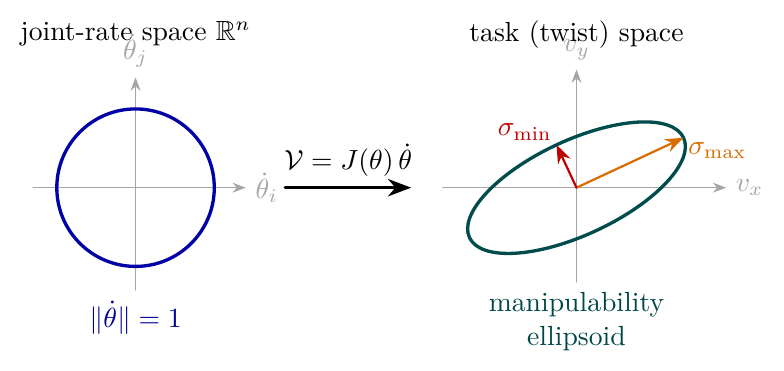

In [3]:
render_tikz_file("_figures/src/jacobian_map.tex", name="jacobian_map")

In [4]:
Js = sm.jacobian(HOME, frame='space')
Jb = sm.jacobian(HOME, frame='body')
print("space Jacobian shape:", Js.shape, " (6 x 7)")

# The two Jacobians are related by the adjoint of the current pose.
T = sm.forward_kinematics(HOME, frame='space')
assert np.allclose(Js, adjoint_transform(T) @ Jb, atol=1e-5)
print("J_s == Ad_T J_b :", True)

space Jacobian shape: (6, 7)  (6 x 7)
J_s == Ad_T J_b : True


## 3. From joint rates to end-effector velocity

The forward velocity map $\mathcal{V}=J\dot\theta$ is implemented directly by `end_effector_velocity`. We check it against the matrix product:

In [5]:
dtheta = np.array([0.1, -0.2, 0.15, 0.05, -0.1, 0.2, 0.1])
V = sm.end_effector_velocity(HOME, dtheta, frame='space')
print("end-effector twist V = [omega; v]:", V)
assert np.allclose(V, Js @ dtheta, atol=1e-9)
print("\nV == J @ dtheta :", True)

end-effector twist V = [omega; v]: [-0.1435 -0.45    0.1562  0.2379 -0.0417 -0.0746]

V == J @ dtheta : True


## 4. The inverse problem: resolved-rate motion

More often we want the reverse: *what joint rates produce a desired end-effector velocity?* Inverting $\mathcal{V}=J\dot\theta$ gives $\dot\theta=J^{\dagger}\mathcal{V}$ with the Moore–Penrose pseudoinverse $J^{\dagger}$ — the basis of **resolved-rate** control. ManipulaPy exposes it as `joint_velocity`.

In [6]:
V_desired = np.array([0, 0, 0, 0.05, 0.0, 0.0])   # move +x at 5 cm/s, no rotation
dtheta_sol = sm.joint_velocity(HOME, V_desired, frame='space')
print("joint rates:", dtheta_sol)

# The recovered joint rates reproduce the requested twist.
assert np.allclose(Js @ dtheta_sol, V_desired, atol=1e-3)
print("\nJ @ dtheta_sol == V_desired :", True)

joint rates: [ 0.      0.1527 -0.      0.147   0.      0.0057  0.    ]

J @ dtheta_sol == V_desired : True


### Resolved rates, live in the simulator

Integrating $\dot\theta=J^{\dagger}\mathcal{V}$ over time turns the rate command into a motion. Below we hold the same twist (+$x$ at 5 cm/s) for 4 s, re-solving `joint_velocity` at every step as the configuration changes, then replay the result in ManipulaPy's **simulation module** (headless PyBullet). `plot_trajectory` draws the end-effector's path as real geometry — the straight orange line the controller was asked to produce.

In [7]:
dt, T_total = 0.05, 4.0
qk = HOME.copy()
q_traj, ee_path = [qk.copy()], [sm.forward_kinematics(qk)[:3, 3]]
for _ in range(int(T_total / dt)):
    dq = sm.joint_velocity(qk, V_desired, frame='space')  # re-solve each step
    qk = qk + dq * dt
    q_traj.append(qk.copy())
    ee_path.append(sm.forward_kinematics(qk)[:3, 3])
ee_path = np.array(ee_path)

disp = ee_path[-1] - ee_path[0]
print("end-effector displacement:", np.round(disp, 4), "m  (expect ~[0.2, 0, 0])")
assert np.allclose(disp, [0.2, 0, 0], atol=5e-3)          # 5 cm/s * 4 s, straight
off_axis = np.abs(ee_path[:, 1:] - ee_path[0, 1:]).max()
print("max off-axis deviation  :", round(off_axis * 1000, 2), "mm")

end-effector displacement: [ 0.1996  0.     -0.0009] m  (expect ~[0.2, 0, 0])
max off-axis deviation  : 0.93 mm


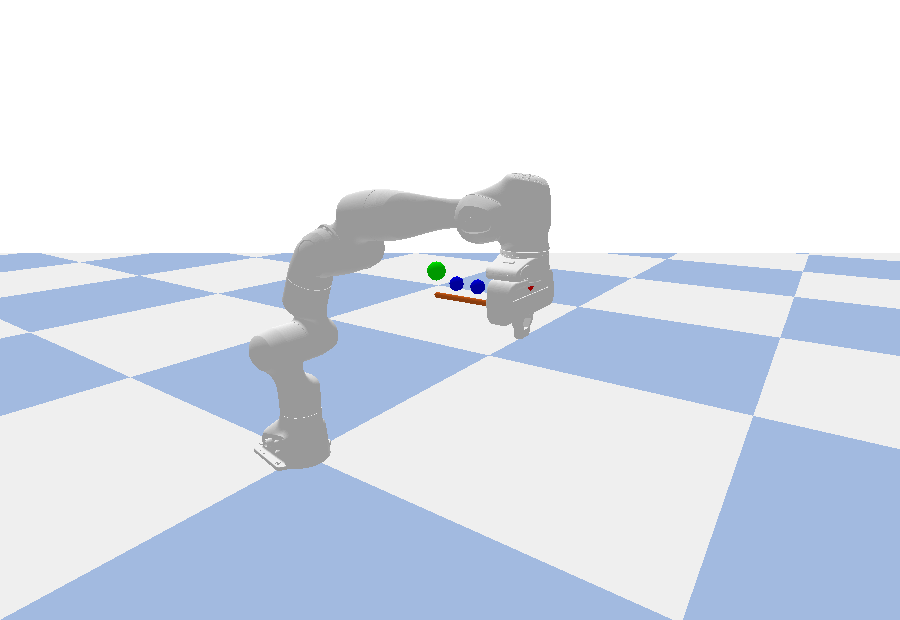

In [8]:
import os
os.environ.setdefault("MANIPULAPY_PYBULLET_CONNECT", "DIRECT")  # headless; remove to watch in a GUI
import logging
from helpers import panda_pybullet_urdf, joint_limits, sim_snapshot, quiet_pybullet
from ManipulaPy.sim import Simulation
import pybullet as p

with quiet_pybullet():
    sim = Simulation(panda_pybullet_urdf(), joint_limits())
# Simulation's logger defaults to DEBUG; keep the notebook output clean.
logging.getLogger("SimulationLogger").setLevel(logging.WARNING)

# Pose the arm at the final configuration; fingers (also non-fixed) padded with 0.
for j, qj in zip(sim.non_fixed_joints, list(q_traj[-1]) + [0.0, 0.0]):
    p.resetJointState(sim.robot_id, j, qj)
sim.plot_trajectory(list(ee_path), line_width=5, color=[0.9, 0.4, 0.1])
img = sim_snapshot("sim_resolved_rate", target=(0.5, 0, 0.5), distance=1.1, yaw=35, pitch=-15)
sim.disconnect_simulation()
img

## 5. Redundancy and the null space

The Panda has **7 joints** but the task space (a twist) is only **6-dimensional**, so $J$ is $6\times7$ — wider than it is tall. At a non-singular configuration it has rank 6, leaving a **1-dimensional null space**: a direction in joint-rate space that produces **zero** end-effector motion. Moving along it reshapes the arm (elbow swivel) while the end-effector stays put. This *self-motion* is what redundancy buys — room to avoid joint limits, obstacles, and singularities while still holding the task pose.

In [9]:
rank = np.linalg.matrix_rank(Js)
print("rank(J):", rank, " -> null-space dimension:", N_JOINTS - rank)

# A null-space joint velocity produces (numerically) zero end-effector twist.
_, _, Vt = np.linalg.svd(Js)
null_dir = Vt[rank]                       # the 1-D null-space basis vector
print("end-effector twist from null-space motion:", np.round(Js @ null_dir, 9))
assert np.allclose(Js @ null_dir, 0, atol=1e-9)

rank(J): 6  -> null-space dimension: 1
end-effector twist from null-space motion: [-0.  0.  0. -0.  0.  0.]


To *see* the self-motion, we follow the null space as a curve: take small steps along the (re-computed) null direction. The arm posture changes substantially while the end-effector barely moves.

In [10]:
# Follow the null-space curve in small steps, keeping the direction consistent.
q = HOME.copy()
ee0 = sm.forward_kinematics(HOME)[:3, 3]
prev = None
for _ in range(20):
    _, _, Vt = np.linalg.svd(sm.jacobian(q, 'space'))
    d = Vt[6]
    if prev is not None and np.dot(d, prev) < 0:
        d = -d
    prev = d
    q = q + 0.04 * d
ee1 = sm.forward_kinematics(q)[:3, 3]
print("largest joint change:", np.round(np.degrees(np.abs(q - HOME)).max(), 1), "deg")
print("end-effector drift  :", round(np.linalg.norm(ee1 - ee0) * 1000, 2), "mm")
assert np.linalg.norm(ee1 - ee0) < 5e-3        # < 5 mm: essentially the same pose

largest joint change: 33.8 deg
end-effector drift  : 1.33 mm


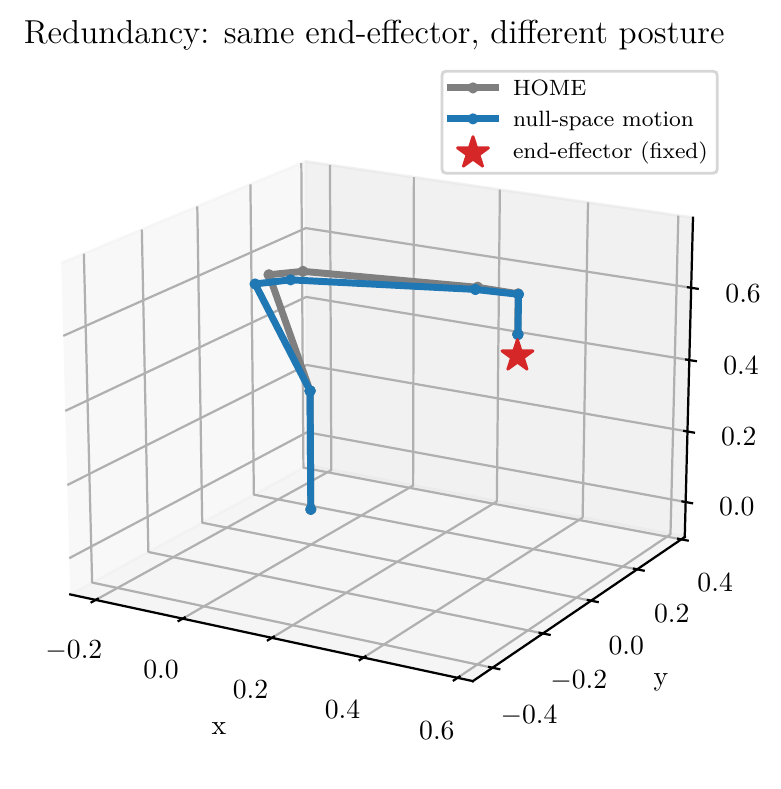

In [11]:
# Draw the two postures (mesh-free, via the URDF module's link_fk) -- same fingertip.
from ManipulaPy.urdf_processor import URDFToSerialManipulator
from helpers import PANDA_URDF
_robot = URDFToSerialManipulator(PANDA_URDF).robot
_arm = [j.name for j in _robot.actuated_joints][:N_JOINTS]
_chain = ["panda_link0", "panda_link1", "panda_link2", "panda_link3", "panda_link4",
          "panda_link5", "panda_link6", "panda_link7", "panda_link8", "panda_hand"]
def link_points(qq):
    lfk = _robot.link_fk(cfg={n: float(qq[i]) for i, n in enumerate(_arm)})
    name2T = {getattr(L, "name", str(L)): T for L, T in lfk.items()}
    return np.array([name2T[n][:3, 3] for n in _chain if n in name2T])

plt = setup_pgf()
fig = plt.figure(figsize=(5.6, 4.6))
ax = fig.add_subplot(projection="3d")
for qq, c, lab in [(HOME, 'tab:gray', 'HOME'), (q, 'tab:blue', 'null-space motion')]:
    P = link_points(qq)
    ax.plot(P[:, 0], P[:, 1], P[:, 2], "-o", color=c, lw=2.5, ms=3, label=lab)
ee = sm.forward_kinematics(HOME)[:3, 3]
ax.scatter(*ee, color="tab:red", marker="*", s=140, label="end-effector (fixed)")
P2 = np.vstack([link_points(HOME), link_points(q)])
lo, hi = P2.min(0) - 0.1, P2.max(0) + 0.1
c0 = (lo + hi) / 2; r = (hi - lo).max() / 2
ax.set_xlim(c0[0]-r, c0[0]+r); ax.set_ylim(c0[1]-r, c0[1]+r); ax.set_zlim(c0[2]-r, c0[2]+r)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z"); ax.view_init(elev=18, azim=-60)
ax.set_title("Redundancy: same end-effector, different posture"); ax.legend(fontsize=8)
embed_pgf_fig(fig, name="null_space_motion")

## 6. A first look at manipulability

How *easily* can the arm move its end-effector in each direction? The **manipulability ellipsoid** answers this: the linear-velocity block $J_v$ of the body Jacobian maps the unit joint-rate ball to an ellipsoid whose axes are the singular values of $J_v$. A scalar summary is $w=\sqrt{\det(J_vJ_v^{\top})}$ — larger means more dexterous, zero means a singularity. Below we draw the velocity ellipse in the $x$–$z$ plane; notebook 06 treats singularities and manipulability in full.

manipulability measure w = 0.13518


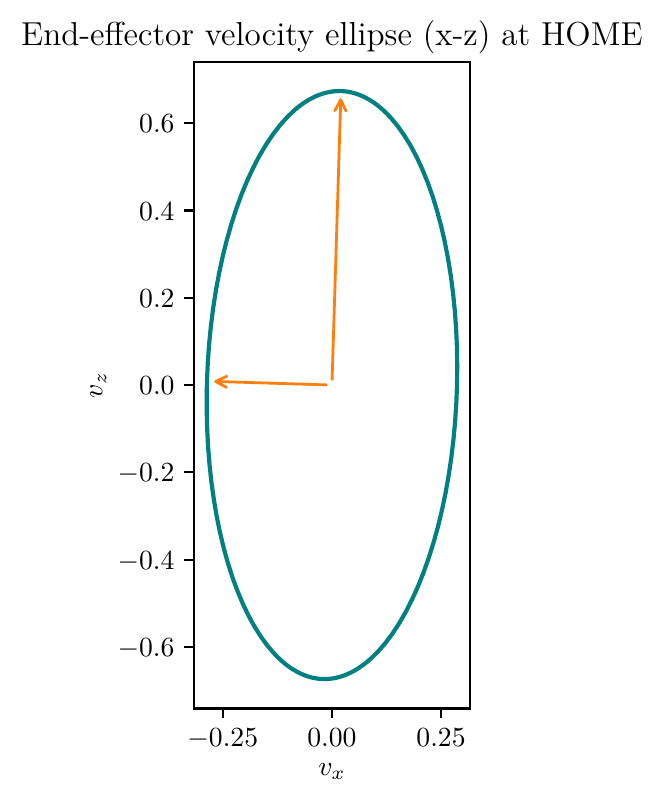

In [12]:
Jv = sm.jacobian(HOME, frame='body')[3:6]      # linear-velocity rows [v]
w = np.sqrt(np.linalg.det(Jv @ Jv.T))
print("manipulability measure w =", round(float(w), 5))

# x-z velocity ellipse: 2x2 block for (v_x, v_z).
Jxz = Jv[[0, 2], :]
A = Jxz @ Jxz.T
evals, evecs = np.linalg.eigh(A)
t = np.linspace(0, 2 * np.pi, 200)
circle = np.vstack([np.cos(t), np.sin(t)])
ellipse = evecs @ np.diag(np.sqrt(evals)) @ circle

plt = setup_pgf()
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.plot(ellipse[0], ellipse[1], color='teal')
for i in range(2):
    vec = evecs[:, i] * np.sqrt(evals[i])
    ax.annotate('', xy=vec, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='tab:orange'))
ax.set_aspect('equal'); ax.set_xlabel('$v_x$'); ax.set_ylabel('$v_z$')
ax.set_title('End-effector velocity ellipse (x-z) at HOME')
embed_pgf_fig(fig, name="velocity_ellipse")

## Smoke test

Asserts the key invariants of this notebook in one cell.

In [13]:
Js = sm.jacobian(HOME, frame='space')
Jb = sm.jacobian(HOME, frame='body')
T = sm.forward_kinematics(HOME, frame='space')
# Shape, forward map, frame relation.
assert Js.shape == (6, N_JOINTS)
dq = np.array([0.1, -0.2, 0.15, 0.05, -0.1, 0.2, 0.1])
assert np.allclose(sm.end_effector_velocity(HOME, dq, 'space'), Js @ dq, atol=1e-9)
assert np.allclose(Js, adjoint_transform(T) @ Jb, atol=1e-5)
# Resolved-rate realizes a desired twist.
Vd = np.array([0, 0, 0, 0.05, 0, 0])
assert np.allclose(Js @ sm.joint_velocity(HOME, Vd, 'space'), Vd, atol=1e-3)
# Redundancy: rank 6, one null direction with zero end-effector twist.
assert np.linalg.matrix_rank(Js) == 6
_, _, Vt = np.linalg.svd(Js)
assert np.allclose(Js @ Vt[6], 0, atol=1e-9)
# Manipulability is positive at this non-singular pose.
Jv = Jb[3:6]
assert np.sqrt(np.linalg.det(Jv @ Jv.T)) > 0
print("nb03 velocity kinematics: smoke OK")

nb03 velocity kinematics: smoke OK


## Try it

1. Command a pure end-effector rotation about $z$ (twist $[0,0,1,0,0,0]$) at `HOME` with `joint_velocity` and confirm the resulting joint rates reproduce it through the Jacobian.
2. Compute the manipulability $w=\sqrt{\det(J_vJ_v^\top)}$ at `HOME` and at a near-singular configuration (e.g. straighten joint 4 toward $0$). How does $w$ change?
3. Take two steps along the null space with opposite sign and verify the end-effector returns to (approximately) the same pose while the elbow swivels both ways.

*Next up — notebook 04: **inverse kinematics**, turning a desired pose back into joint angles, including how redundancy is resolved.*

## References

1. K. M. Lynch and F. C. Park, *Modern Robotics: Mechanics, Planning, and Control*, Cambridge University Press, 2017. — Chapter 5, *Velocity Kinematics and Statics* (space/body Jacobians, manipulability, singularities).
2. R. M. Murray, Z. Li, and S. S. Sastry, *A Mathematical Introduction to Robotic Manipulation*, CRC Press, 1994.
3. B. Siciliano, L. Sciavicco, L. Villani, and G. Oriolo, *Robotics: Modelling, Planning and Control*, Springer, 2009. — Redundancy resolution and the pseudoinverse.
4. ManipulaPy documentation — https://manipulapy.readthedocs.io/ · source — https://github.com/boelnasr/ManipulaPy
